## Importações

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf as pacf_vals_fn
import seaborn as sns
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, TweedieRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Consumindo bases de dados

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/INTERNACOES_DOENCA_RESP_RJ.csv"
url_qualiar     = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/DataRio/QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"

df_internacoes = pd.read_csv(url_internacoes, encoding="utf-8")
df_qualiar     = pd.read_csv(url_qualiar,     encoding="utf-8")

df_unificado = (
    pd.merge(df_qualiar, df_internacoes, on="data_dia", how="inner")
      .sort_values("data_dia")
      .reset_index(drop=True)
)

In [4]:
df_unificado = df_unificado[df_unificado["ano"] < 2020].copy()

df_unificado.tail()

,data_dia,ano,mes,dia,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,AQI,Qualidade_do_Ar,num_internacoes,internacoes_d1,internacoes_d7
2917,2019-12-27,2019,12,27,-0.839592,1.038207,0.353728,-0.029945,-0.691024,-1.237000,-1.168234,2.169538,0.762067,0.299318,0.493213,-2.910890,1.0,266,222.0,230.0
2918,2019-12-28,2019,12,28,-0.839592,1.156305,-0.024235,-0.254014,-1.019149,-1.340539,-1.371467,1.275768,0.589091,-0.547370,-0.114530,-3.184502,1.0,222,170.0,175.0
2919,2019-12-29,2019,12,29,-0.839592,1.056353,-0.311900,-0.601653,-1.537436,-2.414212,-2.434079,0.319829,0.355678,-1.488487,-0.659476,-4.287795,1.0,170,181.0,180.0
2920,2019-12-30,2019,12,30,-0.839592,0.950452,-0.289163,-0.756107,-0.301718,-1.552763,-1.209931,-0.439095,0.597358,-1.679411,-0.869099,-4.287795,1.0,181,115.0,155.0
2921,2019-12-31,2019,12,31,-0.839592,1.374057,-0.506286,-0.526988,-0.166260,-1.136434,-0.859648,0.582399,0.718581,-1.249409,-0.983149,-3.858722,1.0,115,245.0,195.0


### Criação de novas features

In [5]:
def build_feature_dataframe(df_unificado: pd.DataFrame) -> pd.DataFrame:
    """
    Cria um dataframe de modelagem com:
      - alvo: internacoes_d1 (D+1)
      - lags de num_internacoes de 0 a 6
      - médias móveis de num_internacoes nas janelas 7, 14 e 21 (causais)
      - ano_mes_idx = (ano - ano_min) * 12 + mes
      - idx_sazonal_mes_exp: média expandida por mês-do-ano do target_col diário (num_internacoes/internacoes), com shift(1)
      - features ambientais (rolling mean) conforme a tabela (variável, janela, shift)

    Observações de segurança (anti-leak):
      * O alvo é D+1; todas as features são calculadas no máximo até o dia t.
      * Não usamos 'internacoes_d1' para gerar features.
      * Lags e rollings só usam dados históricos (shift >= 0) e rolling inclui a linha corrente (t), o que é seguro para prever t+1.
    """
    # Cópia e ordenação temporal
    df = df_unificado.copy()
    if "data_dia" not in df.columns:
        raise ValueError("Coluna 'data_dia' é obrigatória.")
    df["data_dia"] = pd.to_datetime(df["data_dia"])
    df = df.sort_values("data_dia").reset_index(drop=True)

    # Alvo
    if "internacoes_d1" not in df.columns:
        raise ValueError("Coluna 'internacoes_d1' não encontrada.")
    df["target"] = pd.to_numeric(df["internacoes_d1"], errors="coerce")

    # Garantir ano/mes para o índice composto
    if "ano" not in df.columns:
        df["ano"] = df["data_dia"].dt.year
    if "mes" not in df.columns:
        df["mes"] = df["data_dia"].dt.month

    # ano_mes_idx
    ano_min = int(df["ano"].min())
    df["ano_mes_idx"] = (df["ano"] - ano_min) * 12 + df["mes"]

    # idx_sazonal_mes_exp (média expandida por mês-do-ano do número diário de internações)
    target_col = next((c for c in ["num_internacoes", "internacoes"] if c in df.columns), None)
    if target_col is not None:
        # média expandida por mês (1..12), usando APENAS valores anteriores ao dia atual
        idx_saz = (
            df.groupby(df["data_dia"].dt.month)[target_col]
              .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
              .reset_index(level=0, drop=True)
        )
        df["idx_sazonal_mes_exp"] = idx_saz
    else:
        df["idx_sazonal_mes_exp"] = np.nan  # não deveria acontecer com sua base

    # Lags de num_internacoes (0..6)
    if "num_internacoes" not in df.columns:
        raise ValueError("Coluna 'num_internacoes' não encontrada para criar lags.")
    for k in range(0, 7):
        df[f"num_internacoes_lag{k}"] = df["num_internacoes"].shift(k)

    # Médias móveis causais (janelas 7, 14, 21) de num_internacoes
    # min_periods = janela para respeitar integralmente a janela (evita meia-janela)
    for w in (7, 10, 14, 21, 30):
        df[f"num_internacoes_mm{w}"] = (
            df["num_internacoes"]
              .rolling(window=w, min_periods=w)
              .mean()
        )

    # Tabela de variáveis ambientais com (janela, shift)
    # Interpretação: aplicar shift primeiro (para usar valores até t - shift), depois média móvel causal de 'janela' dias.
    specs = [
        ("o3",   150, 0),
        ("o3",   150, 3),
        ("o3",   150, 5),
        ("no",    60, 0),
        ("so2",  150, 3),
        ("so2",  150, 7),
        ("nox",   60, 0),
        ("no2",   30, 0),
        ("pm10",  30, 0),
    ]

    env_features = []
    for var, janela, sh in specs:
        if var in df.columns:
            serie_shifted = df[var].shift(sh)
            feat_name = f"{var}_rollmean_w{janela}_s{sh}"
            df[feat_name] = serie_shifted.rolling(window=janela, min_periods=janela).mean()
            env_features.append(feat_name)
        # se não existir a coluna, apenas ignora (não cria a feature)

    # Seleção final de colunas (features + alvo)
    feature_cols = (
        [f"num_internacoes_lag{k}" for k in range(0, 7)] +
        [f"num_internacoes_mm{w}" for w in (7, 14, 21)] +
        ["ano_mes_idx", "idx_sazonal_mes_exp"] +
        env_features
    )

    # Construir df_model e remover linhas com NaN (vindos de lags/janelas)
    df_model = df[["data_dia", "target", "ano"] + feature_cols].dropna().reset_index(drop=True)

    # Sanidade: garantir que nenhuma feature usa informações do futuro do ponto de vista de t -> (t+1)
    # (Como todas as operações foram shift/rolling causais com shift >= 0, isso já é assegurado.)
    return df_model

# Exemplo de uso:
df_model = build_feature_dataframe(df_unificado)
df_model.head()


,data_dia,target,ano,num_internacoes_lag0,num_internacoes_lag1,num_internacoes_lag2,num_internacoes_lag3,num_internacoes_lag4,num_internacoes_lag5,num_internacoes_lag6,...,idx_sazonal_mes_exp,o3_rollmean_w150_s0,o3_rollmean_w150_s3,o3_rollmean_w150_s5,no_rollmean_w60_s0,so2_rollmean_w150_s3,so2_rollmean_w150_s7,nox_rollmean_w60_s0,no2_rollmean_w30_s0,pm10_rollmean_w30_s0
0,2012-06-05,936.0,2012,1105,1066.0,559.0,728.0,871.0,754.0,1170.0,...,806.000000,-0.303779,-0.277255,-0.278637,1.136801,0.414301,0.393459,1.034961,1.059812,0.383235
1,2012-06-06,585.0,2012,936,1105.0,1066.0,559.0,728.0,871.0,754.0,...,865.800000,-0.321085,-0.283468,-0.276787,1.174407,0.416940,0.407921,1.061730,1.081700,0.411494
2,2012-06-07,546.0,2012,585,936.0,1105.0,1066.0,559.0,728.0,871.0,...,877.500000,-0.320893,-0.293875,-0.277255,1.179437,0.428246,0.418430,1.058270,1.043066,0.381050
3,2012-06-08,507.0,2012,546,585.0,936.0,1105.0,1066.0,559.0,728.0,...,835.714286,-0.315112,-0.303779,-0.283468,1.200897,0.433921,0.413985,1.064614,1.022174,0.328295
4,2012-06-09,663.0,2012,507,546.0,585.0,936.0,1105.0,1066.0,559.0,...,799.500000,-0.315064,-0.321085,-0.293875,1.187218,0.429439,0.414301,1.052262,0.987779,0.251517


In [6]:
# ===============================
# Previsão de internações D+1
# TimeSeriesSplit + log1p target
# (versão corrigida)
# ===============================

from __future__ import annotations
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor


# ============== Métricas ==============

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calcula o Root Mean Squared Error (RMSE).
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calcula o Mean Absolute Error (MAE).
    """
    return float(mean_absolute_error(y_true, y_pred))


def mape_safe(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-6) -> float:
    """
    Calcula o Mean Absolute Percentage Error (MAPE) de forma robusta a zeros.
    MAPE = mean(|y - y_hat| / max(|y|, eps)) * 100
    """
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100.0)


def r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calcula o R² (coeficiente de determinação).
    """
    return float(r2_score(y_true, y_pred))


# ========== Baseline de Persistência ==========

class PersistenceRegressor(BaseEstimator, RegressorMixin):
    """
    Baseline de persistência: retorna diretamente a coluna de lag usada para prever D+1.
    Ex.: se 'num_internacoes_lag0' representa o valor do dia t, este estimador prevê D+1 = valor(t).

    Parâmetros
    ----------
    col : str
        Nome da coluna em X que será usada como previsão.
    clip_min : float | None
        Se fornecido, aplica np.clip(y_pred, clip_min, None) para evitar negativos.
    """
    def __init__(self, col: str = "num_internacoes_lag0", clip_min: Optional[float] = 0.0):
        self.col = col
        self.clip_min = clip_min

    def fit(self, X: pd.DataFrame, y: np.ndarray | pd.Series):
        # Nada a ajustar (modelo ingênuo)
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        if self.col not in X.columns:
            raise KeyError(f"Coluna '{self.col}' não encontrada em X.")
        yhat = np.asarray(X[self.col], dtype=float)
        if self.clip_min is not None:
            yhat = np.clip(yhat, self.clip_min, None)
        return yhat


# ========== Utilidades de Pesagem / Amostras ==========

def make_peak_weights(y: np.ndarray, alpha: float = 1.0, cap: float = 5.0, power: float = 1.0) -> np.ndarray:
    """
    Gera pesos amostrais para dar mais importância a dias com internações mais altas (para capturar picos).

    w_i = 1 + alpha * (y_i / median(y))**power, limitado por 'cap'.

    Parâmetros
    ----------
    y : array
        Valores do alvo (escala ORIGINAL).
    alpha : float
        Intensidade do aumento de peso.
    cap : float
        Limite superior dos pesos (para evitar explosão).
    power : float
        Exponente que controla a curvatura do crescimento do peso.

    Retorna
    -------
    w : array
        Pesos amostrais do mesmo tamanho de y.
    """
    med = np.median(y) if np.median(y) > 0 else np.mean(y) + 1e-6
    raw = 1.0 + alpha * np.power(np.maximum(y, 0.0) / med, power)
    return np.clip(raw, 1.0, cap)


# ========== Construção dos Modelos Base ==========

def make_ridge_pipeline(alpha: float = 2.0) -> TransformedTargetRegressor:
    """
    Cria um pipeline Ridge linear com padronização dos preditores,
    embrulhado em TransformedTargetRegressor para treinar em log1p(y) e prever em escala original.
    """
    reg = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("ridge",  Ridge(alpha=alpha))
    ])
    return TransformedTargetRegressor(
        regressor=reg,
        func=np.log1p,
        inverse_func=np.expm1
    )


def make_rf_pipeline(
    n_estimators: int = 600,
    max_depth: Optional[int] = None,
    min_samples_leaf: int = 2,
    n_jobs: int = -1,
) -> TransformedTargetRegressor:
    """
    Random Forest embrulhado em TransformedTargetRegressor para log1p(y).

    Observação: RF não usa 'sample_weight' tão bem quanto HGB em séries ruidosas,
    mas ajuda a capturar não linearidades e interações de forma robusta.
    """
    reg = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        n_jobs=n_jobs,
        random_state=42
    )
    return TransformedTargetRegressor(
        regressor=reg,
        func=np.log1p,
        inverse_func=np.expm1
    )


def make_hgb_pipeline(
    learning_rate: float = 0.08,
    max_depth: int = 6,
    max_iter: int = 600,
    l2_regularization: float = 0.0,
) -> TransformedTargetRegressor:
    """
    HistGradientBoostingRegressor (loss quadrático) embrulhado em TransformedTargetRegressor (log1p).
    Tende a lidar bem com não linearidades e pode captar picos melhor que lineares.
    """
    reg = HistGradientBoostingRegressor(
        learning_rate=learning_rate,
        max_depth=max_depth,
        max_iter=max_iter,
        l2_regularization=l2_regularization,
        early_stopping=True,
        random_state=42
    )
    return TransformedTargetRegressor(
        regressor=reg,
        func=np.log1p,
        inverse_func=np.expm1
    )


def make_hgb_peakaware_pipeline(**kwargs) -> TransformedTargetRegressor:
    """
    Igual ao HGB comum, mas preparado para treinar com 'sample_weight' via pesos 'peak-aware'
    (passados em fit como sample_weight).
    """
    return make_hgb_pipeline(**kwargs)


# ========== Híbrido: Base + Booster de Resíduo ==========

@dataclass
class HybridConfig:
    """
    Configuração do modelo híbrido:
      - base: regressor principal (TransformedTargetRegressor com HGB, treinado em log1p(y))
      - booster: regressor dos resíduos (TransformedTargetRegressor com identidade para aceitar resíduos negativos)
      - peso_residual: float multiplicador do resíduo previsto (ajuste fino dos picos)
      - usar_pesos_residuo: se True, aplica pesos focados em resíduos positivos (picos subestimados)
    """
    base: TransformedTargetRegressor
    booster: TransformedTargetRegressor
    peso_residual: float = 1.0
    usar_pesos_residuo: bool = True


def fit_predict_hybrid(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    cfg: HybridConfig
) -> np.ndarray:
    """
    Treina o modelo híbrido:
      1) Ajusta o modelo base em log1p(y).
      2) Prediz em treino e calcula resíduo (y - y_base).
      3) Ajusta o booster nos resíduos (escala original; transformação identidade).
      4) Prediz resíduo no teste e soma ao y_base_test.

    Retorna previsões no ESCALA ORIGINAL (>= 0).
    """
    # 1) Base
    cfg.base.fit(X_train, y_train)
    y_base_tr = cfg.base.predict(X_train)
    y_base_te = cfg.base.predict(X_test)

    # 2) Resíduo (original)
    resid_tr = y_train - y_base_tr

    # 3) Booster com possível ênfase em resíduos positivos (subestimação de picos)
    fit_params = {}
    if cfg.usar_pesos_residuo:
        # dá mais peso quando residual > 0 (picos subestimados pelo base)
        pos_resid = np.maximum(resid_tr, 0.0)
        med = np.median(y_train) if np.median(y_train) > 0 else 1.0
        w_resid = 1.0 + 2.0 * (pos_resid / med)
        w_resid = np.clip(w_resid, 1.0, 8.0)
        fit_params = {"sample_weight": w_resid}

    cfg.booster.fit(X_train, resid_tr, **fit_params)
    resid_te = cfg.booster.predict(X_test)

    # 4) Combina
    y_pred = y_base_te + cfg.peso_residual * resid_te
    return np.clip(y_pred, 0.0, None)


# ========== Preparação de dados ==========

def split_features_target(df_model: pd.DataFrame) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Separa X e y a partir do df_model (saída da sua função build_feature_dataframe).
    Usa 'target' como variável resposta e todas as demais colunas (exceto chaves temporais) como preditores.

    Retorna
    -------
    X : DataFrame
        Features para modelagem.
    y : np.ndarray
        Alvo na escala original (D+1).
    """
    if "target" not in df_model.columns:
        raise KeyError("A coluna 'target' (internacoes_d1) não foi encontrada em df_model.")
    ignore = {"data_dia", "target", "ano"}
    feature_cols = [c for c in df_model.columns if c not in ignore]
    if "num_internacoes_lag0" not in feature_cols:
        raise KeyError("A coluna 'num_internacoes_lag0' não está disponível nas features (necessária para o baseline).")
    X = df_model[feature_cols].copy()
    y = df_model["target"].to_numpy(dtype=float)
    return X, y


# ========== Avaliação com TimeSeriesSplit ==========

def evaluate_models_timeseries(
    X: pd.DataFrame,
    y: np.ndarray,
    n_splits: int = 5,
    peak_weighting_alpha: float = 1.0,
    random_state: int = 42
) -> Tuple[pd.DataFrame, Dict[str, object], Dict[str, List[Dict[str, float]]]]:
    """
    Faz backtest com TimeSeriesSplit para múltiplos modelos, calcula métricas por split e médias.

    Modelos avaliados:
      - baseline_persistencia (num_internacoes_lag0)
      - ridge (log1p)
      - rf (log1p)
      - hgb (log1p)
      - hgb_peakaware (log1p + sample_weight)
      - hybrid_hgb_boost (base HGB + booster HGB nos resíduos, com identidade)

    Parâmetros
    ----------
    X : DataFrame
        Features (de preferência somente variáveis causais/sem vazamento).
    y : array
        Alvo no ESCALA ORIGINAL.
    n_splits : int
        Número de divisões do TimeSeriesSplit.
    peak_weighting_alpha : float
        Intensidade dos pesos “peak-aware” (usado em hgb_peakaware).
    random_state : int
        Semente para reprodutibilidade (quando aplicável).

    Retorna
    -------
    summary_df : DataFrame
        Tabela com métricas médias (RMSE, MAE, MAPE, R2) por modelo.
    fitted_models : dict
        Estimadores finais refitados em TODO o conjunto (para uso futuro).
    fold_details : dict
        Métricas por split para cada modelo.
    """
    # Definição dos estimadores
    models: Dict[str, object] = {
        "baseline_persistencia": PersistenceRegressor(col="num_internacoes_lag0", clip_min=0.0),
        "ridge": make_ridge_pipeline(alpha=2.0),
        "rf": make_rf_pipeline(n_estimators=600, max_depth=None, min_samples_leaf=2, n_jobs=-1),
        "hgb": make_hgb_pipeline(learning_rate=0.08, max_depth=6, max_iter=700, l2_regularization=0.0),
        "hgb_peakaware": make_hgb_peakaware_pipeline(learning_rate=0.07, max_depth=6, max_iter=800, l2_regularization=0.0),
        "hybrid_hgb_boost": HybridConfig(
            base=make_hgb_pipeline(learning_rate=0.07, max_depth=6, max_iter=700, l2_regularization=0.0),
            booster=TransformedTargetRegressor(
                regressor=HistGradientBoostingRegressor(
                    learning_rate=0.06, max_depth=6, max_iter=500, early_stopping=True, random_state=random_state
                ),
                # Booster de resíduos: identidade para aceitar valores negativos
                func=lambda x: x,
                inverse_func=lambda x: x
            ),
            peso_residual=1.0,
            usar_pesos_residuo=True
        )
    }

    # Parâmetros de fit específicos (ex.: pesos para capturar picos)
    def fit_params_for(model_key: str, y_train: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Retorna kwargs de fit específicos por modelo (p.ex., sample_weight para HGB peak-aware).
        """
        if model_key == "hgb_peakaware":
            w = make_peak_weights(y_train, alpha=peak_weighting_alpha, cap=6.0, power=1.0)
            # TransformedTargetRegressor repassa DIRETO para o regressor interno:
            return {"sample_weight": w}
        return {}

    tscv = TimeSeriesSplit(n_splits=n_splits)
    results: Dict[str, List[Dict[str, float]]] = {k: [] for k in models.keys()}

    # Backtesting
    for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        for key, model in models.items():
            if key == "hybrid_hgb_boost":
                # Treino e predição customizada do híbrido
                y_pred = fit_predict_hybrid(X_tr, y_tr, X_te, cfg=model)
            else:
                est = model
                params = fit_params_for(key, y_tr)
                if isinstance(est, TransformedTargetRegressor):
                    # TTR: fit params são passados como kwargs normais (ex.: sample_weight)
                    est.fit(X_tr, y_tr, **params)
                    y_pred = est.predict(X_te)
                else:
                    # Baseline ou outros estimadores diretos
                    est.fit(X_tr, y_tr)
                    y_pred = est.predict(X_te)

            # Clipping em zero, por se tratar de contagem
            y_pred = np.clip(y_pred, 0.0, None)

            fold_metrics = {
                "fold": fold,
                "RMSE": rmse(y_te, y_pred),
                "MAE":  mae(y_te, y_pred),
                "MAPE (%)": mape_safe(y_te, y_pred),
                "R2":   r2(y_te, y_pred)
            }
            results[key].append(fold_metrics)

    # Agrega métricas (média por modelo)
    summary_rows = []
    for key, rows in results.items():
        rmse_m = np.mean([r["RMSE"] for r in rows])
        mae_m  = np.mean([r["MAE"] for r in rows])
        mape_m = np.mean([r["MAPE (%)"] for r in rows])
        r2_m   = np.mean([r["R2"] for r in rows])
        summary_rows.append({
            "modelo": key,
            "RMSE": rmse_m,
            "MAE": mae_m,
            "MAPE (%)": mape_m,
            "R2": r2_m
        })
    summary_df = pd.DataFrame(summary_rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)

    # Refit final em TODO o conjunto (para uso futuro)
    fitted_models: Dict[str, object] = {}
    for key, model in models.items():
        if key == "hybrid_hgb_boost":
            # Reajusta híbrido em todo o conjunto e guarda a config (com modelos treinados)
            cfg: HybridConfig = model
            cfg.base.fit(X, y)
            y_base = cfg.base.predict(X)
            resid = y - y_base

            fit_params = {}
            if cfg.usar_pesos_residuo:
                pos_resid = np.maximum(resid, 0.0)
                med = np.median(y) if np.median(y) > 0 else 1.0
                w_resid = 1.0 + 2.0 * (pos_resid / med)
                w_resid = np.clip(w_resid, 1.0, 8.0)
                fit_params = {"sample_weight": w_resid}

            cfg.booster.fit(X, resid, **fit_params)
            fitted_models[key] = cfg  # guarda a config com base/booster ajustados
        else:
            est = model
            if isinstance(est, TransformedTargetRegressor) and key == "hgb_peakaware":
                params = fit_params_for(key, y)
                est.fit(X, y, **params)
            else:
                est.fit(X, y)
            fitted_models[key] = est

    return summary_df, fitted_models, results


# ========== Predição com modelos treinados ==========

def predict_with(model_obj, X_new: pd.DataFrame) -> np.ndarray:
    """
    Gera previsões em escala ORIGINAL (>=0) para um modelo já treinado e salvo em 'fitted_models'.

    Aceita:
      - TransformedTargetRegressor (qualquer pipeline acima)
      - PersistenceRegressor
      - HybridConfig (híbrido base+booster)
    """
    if isinstance(model_obj, HybridConfig):
        base = model_obj.base.predict(X_new)
        resid = model_obj.booster.predict(X_new)
        yhat = base + model_obj.peso_residual * resid
        return np.clip(yhat, 0.0, None)
    else:
        yhat = model_obj.predict(X_new)
        return np.clip(yhat, 0.0, None)


# ========== Exemplo de uso (cole no seu notebook/script) ==========

# from seu_modulo_features import build_feature_dataframe
df_model = build_feature_dataframe(df_unificado)  # sua função já pronta
#
X, y = split_features_target(df_model)
#
summary, fitted_models, fold_details = evaluate_models_timeseries(
    X, y, n_splits=5, peak_weighting_alpha=1.2
)
#
print(summary)                    # Métricas médias por modelo
# # Ex.: prever com o melhor:
y_hat = predict_with(fitted_models["hybrid_hgb_boost"], X.iloc[-30:])


                  modelo        RMSE        MAE   MAPE (%)        R2
0                     rf   86.104835  65.988062  22.145239  0.484226
1                    hgb   89.801205  68.730771  23.523700  0.441718
2          hgb_peakaware   89.914202  69.720113  24.105520  0.439041
3                  ridge   89.944249  68.841637  22.947728  0.435179
4       hybrid_hgb_boost   95.399250  74.805748  26.554406  0.367184
5  baseline_persistencia  110.553227  83.974752  26.133397  0.165324


In [8]:
# ============================================
# LSTM robusto para previsão D+1 (log1p target)
# TimeSeriesSplit + callbacks + regularização
# ============================================

from __future__ import annotations
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional

import tensorflow as tf
from tensorflow.keras import layers as L, models as M, callbacks as C, optimizers as O, losses as Loss

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ===================== util: fixar sementes =====================

def set_seed(seed: int = 42) -> None:
    """
    Define sementes para reprodutibilidade (NumPy e TensorFlow).
    """
    import os, random
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


# ===================== métricas =====================

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error (RMSE)."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean Absolute Error (MAE)."""
    return float(mean_absolute_error(y_true, y_pred))

def mape_safe(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-6) -> float:
    """
    MAPE robusto a zeros: mean(|y - y_hat| / max(|y|, eps)) * 100.
    """
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100.0)

def r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Coeficiente de determinação R²."""
    return float(r2_score(y_true, y_pred))


# ===================== features/target =====================

def split_features_target(df_model: pd.DataFrame) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Separa X e y do df_model (saída da sua build_feature_dataframe).
    Usa 'target' como resposta (internacoes_d1) e todas as demais colunas (exceto chaves temporais) como features.
    """
    if "target" not in df_model.columns:
        raise KeyError("A coluna 'target' (internacoes_d1) não foi encontrada em df_model.")
    ignore = {"data_dia", "target", "ano"}
    feature_cols = [c for c in df_model.columns if c not in ignore]
    if len(feature_cols) == 0:
        raise ValueError("Nenhuma feature encontrada para modelagem.")
    X = df_model[feature_cols].copy()
    y = df_model["target"].to_numpy(dtype=float)
    return X, y


# ===================== janelamento (sequências) =====================

def build_sequences_from_array(X: np.ndarray, y: np.ndarray, lookback: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Constrói janelas deslizantes de tamanho 'lookback':
      - Para k de lookback-1 até N-1:
          X_seq[k] = X[k-lookback+1 : k+1, :]
          y_seq[k] = y[k]   (alvo D+1 já alinhado na linha k do df_model)
    Retorna:
      X_seq: (n_samples_seq, lookback, n_features)
      y_seq: (n_samples_seq,)
    """
    if lookback < 1:
        raise ValueError("lookback deve ser >= 1.")
    n, f = X.shape
    if n < lookback:
        return np.empty((0, lookback, f)), np.empty((0,))
    out_X, out_y = [], []
    for k in range(lookback - 1, n):
        out_X.append(X[k - lookback + 1 : k + 1, :])
        out_y.append(y[k])
    return np.asarray(out_X, dtype=np.float32), np.asarray(out_y, dtype=np.float32)


def build_test_sequences_with_context(
    X_tr: np.ndarray, y_tr: np.ndarray,
    X_te: np.ndarray, y_te: np.ndarray,
    lookback: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Cria sequências de TESTE usando contexto dos últimos (lookback-1) pontos do treino, sem vazamento.
    Retorna apenas as janelas cujo último passo está no bloco de teste (rótulos = y_te correspondentes).
    """
    if lookback <= 1:
        # sem necessidade de contexto
        return build_sequences_from_array(X_te, y_te, lookback)

    ctx = lookback - 1
    X_cat = np.vstack([X_tr[-ctx:], X_te]) if X_tr.shape[0] >= ctx else np.vstack([X_tr, X_te])
    y_cat = np.concatenate([y_tr[-ctx:], y_te]) if y_tr.shape[0] >= ctx else np.concatenate([y_tr, y_te])

    X_seq_all, y_seq_all = build_sequences_from_array(X_cat, y_cat, lookback)
    # As últimas janelas começam a partir do índice final do contexto
    # Índices de janelas cujo último time step cai no bloco de teste:
    n_seq_all = X_seq_all.shape[0]
    # O primeiro índice de janela que pertence ao teste é exatamente o número de pontos no conjunto expandido
    # menos o tamanho do conjunto de teste (pois cada janela corresponde ao último índice).
    start_te = X_te.shape[0]
    # Corrigindo o mapeamento: como criamos janelas a partir de X_cat, o número de janelas que "cabem"
    # nos primeiros (ctx + len_te) pontos é (ctx + len_te) - lookback + 1.
    # Queremos pegar apenas as janelas cujo último índice está após o contexto: são as últimas len_te janelas.
    X_seq_te = X_seq_all[-X_te.shape[0]:]
    y_seq_te = y_seq_all[-y_te.shape[0]:]
    return X_seq_te, y_seq_te


# ===================== normalização =====================

def scale_train_test(
    X_tr: np.ndarray, X_te: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, StandardScaler]:
    """
    Padroniza features (média 0, desvio 1) com StandardScaler ajustado APENAS no treino.
    """
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    return X_tr_scaled, X_te_scaled, scaler


# ===================== pesos para picos (no espaço log) =====================

def make_peak_weights_log(y_log: np.ndarray, alpha: float = 0.5, cap: float = 3.0, power: float = 1.0) -> np.ndarray:
    """
    Gera pesos amostrais alinhados ao espaço log:
      w = 1 + alpha * ((y_log - med_log)+ / (|med_log| + 1e-6))**power, limitado por 'cap'.
    Útil para dar ênfase a alvos altos mesmo treinando em log1p(y).
    """
    med = np.median(y_log)
    pos = np.maximum(y_log - med, 0.0)
    raw = 1.0 + alpha * np.power(pos / (np.abs(med) + 1e-6), power)
    return np.clip(raw, 1.0, cap).astype(np.float32)


# ===================== arquitetura LSTM (≥5 camadas) =====================

def build_lstm_model(
    input_shape: Tuple[int, int],
    units: Tuple[int, int, int, int, int] = (128, 96, 64, 48, 32),
    dropout: float = 0.2,
    recurrent_dropout: float = 0.1,
    l2_reg: float = 1e-6,
    lr: float = 1e-3,
    huber_delta: float = 1.0,
    clipnorm: float = 1.0
) -> M.Model:
    """
    Constrói um LSTM profundo e robusto:
      - ≥5 camadas LSTM empilhadas (com return_sequences nas 4 primeiras)
      - LayerNormalization entre blocos
      - SpatialDropout1D no início para robustez a ruído em features
      - Cabeça densa pequena com ativação ReLU
      - Otimizador Adam com grad-clip (clipnorm)
      - Perda Huber (robusta a outliers) no espaço log

    input_shape: (lookback, n_features)
    """
    reg = tf.keras.regularizers.l2(l2_reg)

    x_in = L.Input(shape=input_shape)
    x = L.SpatialDropout1D(dropout)(x_in)

    # Bloco LSTM 1
    x = L.LSTM(units[0], return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout,
               kernel_regularizer=reg, recurrent_regularizer=reg)(x)
    x = L.LayerNormalization()(x)

    # Bloco LSTM 2
    x = L.LSTM(units[1], return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout,
               kernel_regularizer=reg, recurrent_regularizer=reg)(x)
    x = L.LayerNormalization()(x)

    # Bloco LSTM 3
    x = L.LSTM(units[2], return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout,
               kernel_regularizer=reg, recurrent_regularizer=reg)(x)
    x = L.LayerNormalization()(x)

    # Bloco LSTM 4
    x = L.LSTM(units[3], return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout,
               kernel_regularizer=reg, recurrent_regularizer=reg)(x)
    x = L.LayerNormalization()(x)

    # Bloco LSTM 5 (último sem return_sequences)
    x = L.LSTM(units[4], return_sequences=False, dropout=dropout, recurrent_dropout=recurrent_dropout,
               kernel_regularizer=reg, recurrent_regularizer=reg)(x)

    # Cabeça densa
    x = L.Dense(64, activation="relu", kernel_regularizer=reg)(x)
    x = L.Dropout(dropout)(x)
    out = L.Dense(1, activation="linear")(x)  # prevê log1p(y)

    model = M.Model(inputs=x_in, outputs=out)
    opt = O.Adam(learning_rate=lr, clipnorm=clipnorm)
    loss = Loss.Huber(delta=huber_delta)  # robusto em log
    model.compile(optimizer=opt, loss=loss)
    return model


# ===================== treinamento + avaliação por dobra =====================

def evaluate_lstm_timeseries(
    X: pd.DataFrame,
    y: np.ndarray,
    n_splits: int = 5,
    lookback: int = 28,
    epochs: int = 250,
    batch_size: int = 32,
    lr: float = 1e-3,
    dropout: float = 0.2,
    recurrent_dropout: float = 0.1,
    l2_reg: float = 1e-6,
    huber_delta: float = 1.0,
    clipnorm: float = 1.0,
    val_fraction: float = 0.2,
    patience_es: int = 30,
    patience_rlr: int = 12,
    use_peak_weights: bool = True,
    peak_alpha: float = 0.5,
    peak_cap: float = 3.0,
    peak_power: float = 1.0,
    seed: int = 42
) -> Tuple[pd.DataFrame, List[Dict[str, float]]]:
    """
    Faz backtest com TimeSeriesSplit para um LSTM profundo (≥5 camadas) treinado em log1p(y)
    e avalia RMSE, MAE, MAPE e R² por dobra + média.

    Técnicas aplicadas:
      - EarlyStopping (paciencia configurável, restaura melhores pesos)
      - ReduceLROnPlateau (reduz LR ao estagnar)
      - Grad clipping (clipnorm)
      - Dropout, recurrent_dropout, SpatialDropout1D
      - LayerNormalization
      - Pesos "peak-aware" opcionais em log (alinha com a perda)

    Retorna:
      summary_df: métricas médias
      fold_details: métricas por fold
    """
    set_seed(seed)
    X_np = X.to_numpy(dtype=np.float32)
    y_np = y.astype(np.float32)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_metrics: List[Dict[str, float]] = []

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_np), start=1):
        X_tr, X_te = X_np[tr_idx], X_np[te_idx]
        y_tr, y_te = y_np[tr_idx], y_np[te_idx]

        # Escalonamento (APENAS com treino)
        X_tr_s, X_te_s, scaler = scale_train_test(X_tr, X_te)

        # Janelamento
        Xtr_seq, ytr = build_sequences_from_array(X_tr_s, y_tr, lookback=lookback)
        Xte_seq, yte = build_test_sequences_with_context(X_tr_s, y_tr, X_te_s, y_te, lookback=lookback)

        # Transforma alvo para log1p
        ytr_log = np.log1p(ytr).astype(np.float32)

        if Xtr_seq.shape[0] == 0 or Xte_seq.shape[0] == 0:
            raise ValueError(f"Dobra {fold}: não há amostras suficientes para lookback={lookback}.")

        # Pesos "peak-aware" no espaço log (opcionais)
        sample_weight = None
        if use_peak_weights:
            sample_weight = make_peak_weights_log(ytr_log, alpha=peak_alpha, cap=peak_cap, power=peak_power)

        # Modelo
        model = build_lstm_model(
            input_shape=(Xtr_seq.shape[1], Xtr_seq.shape[2]),
            units=(128, 96, 64, 48, 32),
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            l2_reg=l2_reg,
            lr=lr,
            huber_delta=huber_delta,
            clipnorm=clipnorm
        )

        # Callbacks (validação é a cauda do treino, respeitando ordem temporal)
        n_val = max(1, int(np.floor(val_fraction * Xtr_seq.shape[0])))
        X_tr_fold, X_val_fold = Xtr_seq[:-n_val], Xtr_seq[-n_val:]
        y_tr_fold, y_val_fold = ytr_log[:-n_val], ytr_log[-n_val:]
        sw_tr_fold = sample_weight[:-n_val] if sample_weight is not None else None
        sw_val_fold = sample_weight[-n_val:] if sample_weight is not None else None  # só para monitoramento (não usado por fit)

        es = C.EarlyStopping(monitor="val_loss", patience=patience_es, restore_best_weights=True, min_delta=1e-4)
        rlr = C.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=patience_rlr, min_lr=1e-5, verbose=0)

        # Treino
        model.fit(
            X_tr_fold, y_tr_fold,
            validation_data=(X_val_fold, y_val_fold),
            sample_weight=sw_tr_fold,
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,  # importantíssimo em séries temporais
            callbacks=[es, rlr],
            verbose=0
        )

        # Predição (em log) → volta ao original com expm1
        y_pred_log = model.predict(Xte_seq, batch_size=batch_size, verbose=0).ravel()
        y_pred = np.expm1(y_pred_log).astype(np.float32)
        y_pred = np.clip(y_pred, 0.0, None)

        # Métricas na escala original
        fold_res = {
            "fold": fold,
            "RMSE": rmse(yte, y_pred),
            "MAE": mae(yte, y_pred),
            "MAPE (%)": mape_safe(yte, y_pred),
            "R2": r2(yte, y_pred)
        }
        fold_metrics.append(fold_res)

    # Média
    summary = {
        "modelo": "lstm_stacked",
        "RMSE": float(np.mean([m["RMSE"] for m in fold_metrics])),
        "MAE": float(np.mean([m["MAE"] for m in fold_metrics])),
        "MAPE (%)": float(np.mean([m["MAPE (%)"] for m in fold_metrics])),
        "R2": float(np.mean([m["R2"] for m in fold_metrics]))
    }
    summary_df = pd.DataFrame([summary])
    return summary_df, fold_metrics


In [9]:
# --- se você já tem: build_feature_dataframe(df_unificado) ---
# df_model = build_feature_dataframe(df_unificado)

# 1) Separar features e alvo (usa a função do LSTM que te passei)
X, y = split_features_target(df_model)

# 2) Rodar o LSTM com TimeSeriesSplit
summary_lstm, fold_details_lstm = evaluate_lstm_timeseries(
    X, y,
    n_splits=5,        # nº de dobras (ajuste se quiser)
    lookback=28,       # janela temporal (28 é um bom ponto de partida; 42/56 se houver dados)
    epochs=250,
    batch_size=32,
    lr=1e-3,
    dropout=0.2,
    recurrent_dropout=0.1,
    l2_reg=1e-6,
    huber_delta=1.0,
    clipnorm=1.0,
    val_fraction=0.2,
    patience_es=30,
    patience_rlr=12,
    use_peak_weights=True,  # ênfase opcional em picos (no espaço log)
    peak_alpha=0.5,
    peak_cap=3.0,
    peak_power=1.0,
    seed=42
)

print("Resumo LSTM (média das dobras):")
print(summary_lstm)

print("\nMétricas por dobra:")
for m in fold_details_lstm:
    print(m)


Resumo LSTM (média das dobras):
         modelo       RMSE        MAE   MAPE (%)        R2
0  lstm_stacked  91.640216  73.200688  41.794947  0.076659

Métricas por dobra:
{'fold': 1, 'RMSE': 113.96960258112686, 'MAE': 90.12113189697266, 'MAPE (%)': 26.96661376953125, 'R2': 0.5280229449272156}
{'fold': 2, 'RMSE': 114.85499094646475, 'MAE': 92.83042907714844, 'MAPE (%)': 38.440147399902344, 'R2': -0.058754801750183105}
{'fold': 3, 'RMSE': 84.93839392005685, 'MAE': 62.06614685058594, 'MAPE (%)': 22.424333572387695, 'R2': 0.4573156237602234}
{'fold': 4, 'RMSE': 67.45738310338054, 'MAE': 55.532196044921875, 'MAPE (%)': 38.06026077270508, 'R2': -0.37212538719177246}
{'fold': 5, 'RMSE': 76.98070730303145, 'MAE': 65.45353698730469, 'MAPE (%)': 83.08338165283203, 'R2': -0.1711651086807251}


## Pipeline 1 — Visão geral
Este pipeline prevê internações por doenças respiratórias D+1

Recursos principais:
  - Split temporal (treino/validação/teste) sem vazamento
  - Baseline de persistência (lag0)
  - Modelos: Ridge (alvo em log1p), HistGradientBoosting (Poisson), Tweedie (link log)
  - Ensemble (stacking) com meta-aprendiz Ridge
  - Métricas: RMSE, MAE, MAPE, sMAPE (geral e “dias de salto”)
  - Intervalos preditivos (q10–q90) via Gradient Boosting quantílico
  - Engenharia de features leve: lags, médias móveis, volatilidade, deltas, calendário (DOW/DOY)

Objetivo do V1: estabelecer um baseline forte e um conjunto de modelos comparáveis, garantindo integridade temporal e reprodutibilidade.

### Métricas

In [ ]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def mape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true > 0
    if not np.any(mask):
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + eps))) * 100.0)

def smape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps) / 2.0
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100.0)

def evaluate_all(y_true, y_pred) -> Dict[str, float]:
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "MAPE (%)": mape(y_true, y_pred),
        "sMAPE (%)": smape(y_true, y_pred),
    }

### Engenharia de variáveis (função add_derived_features)
Cria sinais para picos/saltos sem vazamento:
  - volatilidade7: desvio-padrão dos últimos 7 dias (lags 0..6)
  - delta_abs_1, delta_rel_1: variação t vs t−1
  - delta_abs_7, delta_rel_7: variação t vs t−6
  - Calendário: dow (0–6), codificação cíclica de dia-do-ano: doy_sin, doy_cos.

Motivação: volatilidade e deltas ajudam modelos a “enxergar” transições rápidas onde o baseline falha.

In [ ]:
def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria features adicionais que ajudam a capturar movimentos bruscos (saltos)
    sem causar vazamento (usando apenas lags já presentes).
    - volatilidade7: desvio-padrão dos últimos 7 dias (~lags 0..6)
    - delta_abs_1: |lag0 - lag1|
    - delta_rel_1: (lag0 - lag1)/(lag1+1)
    - delta_abs_7: |lag0 - lag6|
    - delta_rel_7: (lag0 - lag6)/(lag6+1)
    - dows (one-hot): dia da semana do 'data_dia'
    - sazonalidade cíclica simplificada: sin/cos do dia-do-ano
    """
    df = df.copy()
    lag_cols = [c for c in df.columns if c.startswith("num_internacoes_lag")]
    # Garantir que temos pelo menos lag0..lag6
    needed = [f"num_internacoes_lag{k}" for k in range(0,7)]
    if all(c in df.columns for c in needed):
        arr = df[needed].values.astype(float)
        df["volatilidade7"] = np.nanstd(arr, axis=1)
        df["delta_abs_1"] = np.abs(df["num_internacoes_lag0"] - df["num_internacoes_lag1"])
        df["delta_rel_1"] = (df["num_internacoes_lag0"] - df["num_internacoes_lag1"]) / (df["num_internacoes_lag1"] + 1.0)
        df["delta_abs_7"] = np.abs(df["num_internacoes_lag0"] - df["num_internacoes_lag6"])
        df["delta_rel_7"] = (df["num_internacoes_lag0"] - df["num_internacoes_lag6"]) / (df["num_internacoes_lag6"] + 1.0)
    else:
        # Fallback seguro
        df["volatilidade7"] = df.get("num_internacoes_mm7", pd.Series(0, index=df.index))
        df["delta_abs_1"] = 0.0
        df["delta_rel_1"] = 0.0
        df["delta_abs_7"] = 0.0
        df["delta_rel_7"] = 0.0

    # Calendário
    if "data_dia" in df.columns:
        ser = pd.to_datetime(df["data_dia"])
        df["dow"] = ser.dt.dayofweek  # 0=segunda
        df["doy"] = ser.dt.dayofyear
        # codificação cíclica
        df["doy_sin"] = np.sin(2*np.pi * df["doy"] / 366.0)
        df["doy_cos"] = np.cos(2*np.pi * df["doy"] / 366.0)
    else:
        df["dow"] = 0
        df["doy_sin"] = 0.0
        df["doy_cos"] = 0.0
    return df

### Divisão temporal (função time_based_split)
Particiona por datas reais:
  - Treino: início → valid_start
  - Validação: valid_start → test_start
  - Teste: test_start → fim
  Parâmetros padrão: valid_days=365, test_days=365.


In [4]:
@dataclass
class Split:
    train_idx: np.ndarray
    valid_idx: np.ndarray
    test_idx: np.ndarray

def time_based_split(dates: pd.Series, valid_days: int = 365, test_days: int = 365) -> Split:
    dates = pd.to_datetime(dates)
    end_date = dates.max()
    test_start = end_date - pd.Timedelta(days=test_days-1)
    valid_start = test_start - pd.Timedelta(days=valid_days)
    train_mask = dates < valid_start
    valid_mask = (dates >= valid_start) & (dates < test_start)
    test_mask  = dates >= test_start
    return Split(np.where(train_mask)[0], np.where(valid_mask)[0], np.where(test_mask)[0])

### Preparação de matrizes (função build_matrices)
- Define X/y e preprocessador:
  - Numéricas → StandardScaler
  - Categóricas (dow) → OneHotEncoder
- Retorna: X, y, nomes de features e preprocessor para pipelines lineares.
Nota: para HGB Poisson usamos X numérico (dummies de dow pela função select_columns_for_hgb).

In [ ]:
def build_matrices(df_model: pd.DataFrame, extra_onehot: bool = True) -> Tuple[pd.DataFrame, np.ndarray, List[str], ColumnTransformer]:
    """
    Separa X, y e prepara transformações por tipo de variável para modelos lineares.
    """
    df = add_derived_features(df_model)

    y = df["target"].values.astype(float)
    # Features candidatas: tudo exceto colunas óbvias de não-feature
    exclude = {"target", "internacoes_d1"}
    # vamos manter 'ano' e 'ano_mes_idx' como numéricas
    num_cols = []
    cat_cols = []
    for c in df.columns:
        if c in exclude: continue
        if c == "data_dia": continue
        if df[c].dtype.kind in "biufc":  # numeric
            num_cols.append(c)
        else:
            cat_cols.append(c)

    # Opcionalmente forçar 'dow' como categórica
    if extra_onehot and "dow" in df.columns:
        if "dow" in num_cols:
            num_cols.remove("dow")
        if "dow" not in cat_cols:
            cat_cols.append("dow")

    # Transformadores
    numeric_transformer = Pipeline(steps=[("scaler", StandardScaler(with_mean=True, with_std=True))])
    categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]) if cat_cols else "drop"

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ]
    )

    X = df[num_cols + cat_cols].copy()  # manter DataFrame para referências
    feature_names = num_cols + cat_cols
    return X, y, feature_names, preprocessor

### Modelos (V1)
1. Ridge (alvo em log1p)
    - Treino em log1p(y) e predição com expm1 (clip ≥ 0).
    - Reduz heterocedasticidade; forte como baseline “linear”.

2. HistGradientBoostingRegressor (Poisson)
    - Natural para contagem com variância crescente.
    - Bom em não linearidades e saltos (melhor que linear em picos).

3. TweedieRegressor (link log)
    - Intermédio entre Poisson e Gamma; robusto a superdispersão.

Sugestão: registrar hiperparâmetros e seeds para reprodutibilidade.

In [ ]:
def fit_ridge_log(X, y, preprocessor: ColumnTransformer, alpha: float = 5.0) -> Pipeline:
    """
    Modelo linear em log1p do alvo. Predição é invertida com expm1 e truncada em 0.
    """
    model = Pipeline(steps=[
        ("prep", preprocessor),
        ("ridge", Ridge(alpha=alpha, random_state=42))
    ])
    # y transformado
    y_log = np.log1p(y)
    model.fit(X, y_log)
    return model

def predict_ridge_log(model: Pipeline, X) -> np.ndarray:
    y_log_pred = model.predict(X)
    y_pred = np.expm1(y_log_pred)
    return np.clip(y_pred, 0.0, None)

def fit_hgb_poisson(X, y) -> HistGradientBoostingRegressor:
    """
    HGB Regressor com perda Poisson: adequado para contagens com variância crescente.
    """
    # HistGBR não aceita preprocessors do sklearn diretamente via ColumnTransformer,
    # então usamos dummies para categóricas mais simples (dow já foi one-hot no preprocessor? Aqui assumimos apenas numéricas).
    # Para simplicidade, usamos apenas colunas numéricas já contínuas (incluindo dummies se você as tiver criado).
    # Se precisar de one-hot, crie antes e passe no X.
    model = HistGradientBoostingRegressor(
        loss="poisson",
        learning_rate=0.05,
        max_depth=None,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=1.0,
        early_stopping=True,
        random_state=42
    )
    y_pos = np.clip(y, 0, None)
    model.fit(X, y_pos)
    return model

def fit_tweedie_loglink(X, y, alpha: float = 0.001, power: float = 1.3) -> Pipeline:
    """
    Tweedie (1<p<2) com link log; robusto para dados de contagem superdispersos.
    """
    num_cols = X.columns.tolist()
    preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols)])
    model = Pipeline(steps=[
        ("prep", preprocessor),
        ("tweedie", TweedieRegressor(power=power, alpha=alpha, link="log", max_iter=1000))
    ])
    y_pos = np.clip(y, 0, None)
    model.fit(X, y_pos)
    return model

def fit_quantile_gbr(X, y, alpha_q: float = 0.9) -> GradientBoostingRegressor:
    return GradientBoostingRegressor(
        loss="quantile",
        alpha=alpha_q,
        learning_rate=0.05,
        n_estimators=400,
        max_depth=3,
        random_state=42
    ).fit(X, y)

### Ensemble (stacking)
  - Meta-aprendiz: Ridge
  - Entradas: predições (ridge, hgb_poisson, tweedie) + lag0 e volatilidade7
  - Objetivo: combinar “forças” dos modelos base.

Observação: em séries com forte inércia, o meta-modelo pode dar mais peso a lag0.

In [ ]:
def select_columns_for_hgb(X: pd.DataFrame) -> pd.DataFrame:
  """
  HGBR precisa de matriz numérica. Vamos converter 'dow' em dummies se existir.
  """
  Xh = X.copy()
  if "dow" in Xh.columns and not np.issubdtype(Xh["dow"].dtype, np.number):
      Xh = pd.get_dummies(Xh, columns=["dow"], drop_first=False)
  elif "dow" in Xh.columns:
      # garantir dummies mesmo se for int
      Xh = pd.get_dummies(Xh, columns=["dow"], drop_first=False)
  return Xh

In [ ]:

"""
resp_internacoes_modeling.py
---------------------------------
Pipeline robusto para prever internações por doenças respiratórias (D+1)
com suporte a:
- divisão temporal (treino/val/teste) sem vazamento
- baseline de persistência (lag0)
- modelos: Ridge em log1p, HistGradientBoosting (Poisson), Tweedie (log link)
- ensemble (stacking) com meta-aprendiz (Ridge)
- métricas: RMSE, MAE, MAPE, sMAPE (gerais e em dias de salto)
- intervalos preditivos via GradientBoosting quantílico (opcional)
- engenharia leve de features derivadas dos lags (volatilidade, variações)
Autor: você + ChatGPT
"""









# =====================
# Modelos
# =====================


# =====================
# Avaliação e Ensemble
# =====================



def evaluate_models(df_model: pd.DataFrame, valid_days: int = 365, test_days: int = 365) -> Dict:
    # Build matrices and split
    X, y, feat_names, preproc = build_matrices(df_model)
    dates = pd.to_datetime(df_model["data_dia"])

    split = time_based_split(dates, valid_days=valid_days, test_days=test_days)
    Xtr, ytr = X.iloc[split.train_idx], y[split.train_idx]
    Xva, yva = X.iloc[split.valid_idx], y[split.valid_idx]
    Xte, yte = X.iloc[split.test_idx], y[split.test_idx]

    # Baseline persistência: usa lag0 na mesma linha para prever D+1
    if "num_internacoes_lag0" not in X.columns:
        raise ValueError("Feature 'num_internacoes_lag0' é necessária para o baseline de persistência.")
    baseline_pred_va = Xva["num_internacoes_lag0"].values.astype(float)
    baseline_pred_te = Xte["num_internacoes_lag0"].values.astype(float)

    # Ridge em log1p
    ridge_log = fit_ridge_log(Xtr, ytr, preproc, alpha=5.0)
    ridge_va = predict_ridge_log(ridge_log, Xva)
    ridge_te = predict_ridge_log(ridge_log, Xte)

    # HGB Poisson (sem pré-processamento, trabalha no X numérico)
    Xtr_hgb = select_columns_for_hgb(Xtr)
    Xva_hgb = select_columns_for_hgb(Xva)
    Xte_hgb = select_columns_for_hgb(Xte)
    hgb = fit_hgb_poisson(Xtr_hgb, ytr)
    hgb_va = np.clip(hgb.predict(Xva_hgb), 0.0, None)
    hgb_te = np.clip(hgb.predict(Xte_hgb), 0.0, None)

    # Tweedie log link
    tweedie = fit_tweedie_loglink(Xtr, ytr, alpha=1e-3, power=1.3)
    tw_va = np.clip(tweedie.predict(Xva), 0.0, None)
    tw_te = np.clip(tweedie.predict(Xte), 0.0, None)

    # Stacking simples (meta Ridge) com as 3 predições + lag0 e volatilidade
    def _stack_feats(Xslice, preds_list):
        cols = [preds_list[0], preds_list[1], preds_list[2]]
        Z = np.vstack(cols).T  # (n, 3)
        extra = []
        if "num_internacoes_lag0" in Xslice.columns:
            extra.append(Xslice["num_internacoes_lag0"].values.astype(float))
        if "volatilidade7" in Xslice.columns:
            extra.append(Xslice["volatilidade7"].values.astype(float))
        if extra:
            Z = np.column_stack([Z] + extra)
        return Z

    Zva = _stack_feats(Xva, [ridge_va, hgb_va, tw_va])
    Zte = _stack_feats(Xte, [ridge_te, hgb_te, tw_te])

    meta = Ridge(alpha=1.0, random_state=42)
    meta.fit(Zva, yva)
    stack_va = np.clip(meta.predict(Zva), 0.0, None)
    stack_te = np.clip(meta.predict(Zte), 0.0, None)

    # Avaliação geral
    results = {
        "baseline_persistencia": {
            "valid": evaluate_all(yva, baseline_pred_va),
            "test": evaluate_all(yte, baseline_pred_te),
        },
        "ridge_log": {
            "valid": evaluate_all(yva, ridge_va),
            "test": evaluate_all(yte, ridge_te),
        },
        "hgb_poisson": {
            "valid": evaluate_all(yva, hgb_va),
            "test": evaluate_all(yte, hgb_te),
        },
        "tweedie_log": {
            "valid": evaluate_all(yva, tw_va),
            "test": evaluate_all(yte, tw_te),
        },
        "stacking_meta_ridge": {
            "valid": evaluate_all(yva, stack_va),
            "test": evaluate_all(yte, stack_te),
        }
    }

    # Métricas focadas em dias de salto (mudança abrupta vs lag0)
    # definimos "salto" se |y_true - lag0| >= max(0.5*y_true, 80)
    def jump_mask(Xslice, yslice):
        if "num_internacoes_lag0" not in Xslice.columns:
            return np.zeros_like(yslice, dtype=bool)
        lag0 = Xslice["num_internacoes_lag0"].values.astype(float)
        return np.abs(yslice - lag0) >= np.maximum(0.5 * np.maximum(yslice, 1.0), 80.0)

    jmask_va = jump_mask(Xva, yva)
    jmask_te = jump_mask(Xte, yte)

    def eval_jumps(y, pred, mask):
        if not np.any(mask):
            return {"RMSE": np.nan, "MAE": np.nan, "MAPE (%)": np.nan, "sMAPE (%)": np.nan, "n": int(mask.sum())}
        m = evaluate_all(y[mask], pred[mask])
        m["n"] = int(mask.sum())
        return m

    results_jumps = {
        "baseline_persistencia": {
            "valid": eval_jumps(yva, baseline_pred_va, jmask_va),
            "test": eval_jumps(yte, baseline_pred_te, jmask_te),
        },
        "ridge_log": {
            "valid": eval_jumps(yva, ridge_va, jmask_va),
            "test": eval_jumps(yte, ridge_te, jmask_te),
        },
        "hgb_poisson": {
            "valid": eval_jumps(yva, hgb_va, jmask_va),
            "test": eval_jumps(yte, hgb_te, jmask_te),
        },
        "tweedie_log": {
            "valid": eval_jumps(yva, tw_va, jmask_va),
            "test": eval_jumps(yte, tw_te, jmask_te),
        },
        "stacking_meta_ridge": {
            "valid": eval_jumps(yva, stack_va, jmask_va),
            "test": eval_jumps(yte, stack_te, jmask_te),
        }
    }

    # Intervalos preditivos (opcionais) no conjunto de teste a partir do melhor modelo (stacking)
    # Ajustamos quantis em (train+valid) e prevemos no teste
    Xtrva = pd.concat([Xtr, Xva], axis=0)
    ytrva  = np.concatenate([ytr, yva], axis=0)
    q10 = fit_quantile_gbr(select_columns_for_hgb(Xtrva), ytrva, alpha_q=0.10)
    q90 = fit_quantile_gbr(select_columns_for_hgb(Xtrva), ytrva, alpha_q=0.90)
    ints = {
        "q10": np.clip(q10.predict(select_columns_for_hgb(Xte)), 0.0, None),
        "q90": np.clip(q90.predict(select_columns_for_hgb(Xte)), 0.0, None),
    }

    # Coletar também as predições finais (teste)
    preds = {
        "dates_test": pd.to_datetime(dates.iloc[split.test_idx]).tolist(),
        "y_test": yte.tolist(),
        "baseline_test": baseline_pred_te.tolist(),
        "ridge_log_test": ridge_te.tolist(),
        "hgb_poisson_test": hgb_te.tolist(),
        "tweedie_log_test": tw_te.tolist(),
        "stack_test": stack_te.tolist(),
        "q10_test": ints["q10"].tolist(),
        "q90_test": ints["q90"].tolist(),
    }

    # Importâncias do HGB (apenas para interpretação)
    try:
        importances = dict(zip(select_columns_for_hgb(Xtr).columns.tolist(),
                               hgb.feature_importances_.tolist()))
    except Exception:
        importances = {}

    out = {
        "metrics_overall": results,
        "metrics_jumps": results_jumps,
        "feature_names": feat_names,
        "hgb_feature_importances": importances,
        "predictions_test": preds,
        "split_sizes": {
            "train": int(len(split.train_idx)),
            "valid": int(len(split.valid_idx)),
            "test": int(len(split.test_idx)),
        }
    }
    return out

# =====================
# Uso
# =====================
"""
Exemplo (no seu notebook/script principal, onde já existe df_model):
------------------------------------------------------------
from resp_internacoes_modeling import evaluate_models

resultados = evaluate_models(df_model, valid_days=365, test_days=365)

# Tabela de métricas (teste)
import pandas as pd
tabela = pd.DataFrame({k: v["test"] for k, v in resultados["metrics_overall"].items()}).T
tabela

# Métricas focadas em dias de salto (teste)
tabela_jumps = pd.DataFrame({k: v["test"] for k, v in resultados["metrics_jumps"].items()}).T
tabela_jumps

# Predições com intervalos (para plot)
preds = resultados["predictions_test"]
df_pred = pd.DataFrame({
    "data_dia": preds["dates_test"],
    "y_true": preds["y_test"],
    "y_pred_stack": preds["stack_test"],
    "q10": preds["q10_test"],
    "q90": preds["q90_test"],
})
"""

resultados = evaluate_models(df_model, valid_days=365, test_days=365)

# Tabela de métricas (teste)
import pandas as pd
tabela = pd.DataFrame({k: v["test"] for k, v in resultados["metrics_overall"].items()}).T
tabela

# Métricas focadas em dias de salto (teste)
tabela_jumps = pd.DataFrame({k: v["test"] for k, v in resultados["metrics_jumps"].items()}).T
tabela_jumps

# Predições com intervalos (para plot)
preds = resultados["predictions_test"]
df_pred = pd.DataFrame({
    "data_dia": preds["dates_test"],
    "y_true": preds["y_test"],
    "y_pred_stack": preds["stack_test"],
    "q10": preds["q10_test"],
    "q90": preds["q90_test"],
})


In [20]:
# 365 dias p/ validação + 365 p/ teste (ajuste se quiser)
result = evaluate_models(df_model, valid_days=365, test_days=365)

# Tabela de métricas (teste)
tabela = pd.DataFrame({k: v["test"] for k, v in result["metrics_overall"].items()}).T
display(tabela.sort_values("RMSE"))

# Tabela de métricas só em dias de salto (teste)
tabela_jumps = pd.DataFrame({k: v["test"] for k, v in result["metrics_jumps"].items()}).T
display(tabela_jumps.sort_values("RMSE"))

,RMSE,MAE,MAPE (%),sMAPE (%)
baseline_persistencia,28.780983,19.665000,23.812769,22.922388
stacking_meta_ridge,35.648201,30.515148,54.651516,38.159713
ridge_log,69.436625,65.402460,117.149999,63.816566
hgb_poisson,76.661585,72.078458,133.851313,67.957687
tweedie_log,79.933056,77.013708,135.893080,70.610576


,RMSE,MAE,MAPE (%),sMAPE (%),n
hgb_poisson,58.086454,51.517457,43.795623,34.373210,5.0
tweedie_log,60.053496,54.612905,46.297641,36.326171,5.0
ridge_log,70.090634,67.006591,54.104434,44.137589,5.0
stacking_meta_ridge,74.680824,74.023443,53.557548,50.493376,5.0
baseline_persistencia,110.614646,110.000000,80.329586,77.490280,5.0


## Pipeline 2

In [9]:

"""
resp_internacoes_modeling.py — v2
---------------------------------
Pipeline robusto para prever internações por doenças respiratórias (D+1)
com foco em:
- divisão temporal (treino/val/teste) sem vazamento
- baseline de persistência (lag0)
- modelos: Ridge em log1p, HistGradientBoosting (Poisson), Tweedie (log link)
- modelo de RESÍDUO (delta_log) que corrige o baseline (foco em picos)
- ponderação por amostra para dar mais peso a "dias de salto"
- ensemble simples (stacking) opcional
- estratégia HÍBRIDA (baseline ↔ modelo) com busca automática de limiares na validação
- métricas: RMSE, MAE, MAPE, sMAPE (gerais e em dias de salto)
- intervalos preditivos via GradientBoosting quantílico
- features derivadas dos lags (volatilidade, deltas), calendário (dow, ciclo anual)
- funções utilitárias para plot e export
Autor: você + ChatGPT
"""

# from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, TweedieRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# =====================
# Utilidades de métrica
# =====================

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def mape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true > 0
    if not np.any(mask):
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + eps))) * 100.0)

def smape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps) / 2.0
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100.0)

def evaluate_all(y_true, y_pred) -> Dict[str, float]:
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "MAPE (%)": mape(y_true, y_pred),
        "sMAPE (%)": smape(y_true, y_pred),
    }

# =====================
# Preparação de dados
# =====================

def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria features adicionais que ajudam a capturar movimentos bruscos (saltos)
    sem causar vazamento (usando apenas lags já presentes).
    - volatilidade7: desvio-padrão dos últimos 7 dias (~lags 0..6)
    - delta_abs_1: |lag0 - lag1|
    - delta_rel_1: (lag0 - lag1)/(lag1+1)
    - delta_abs_7: |lag0 - lag6|
    - delta_rel_7: (lag0 - lag6)/(lag6+1)
    - dow (0..6): dia da semana de data_dia
    - sazonalidade cíclica: sin/cos do dia-do-ano
    """
    df = df.copy()
    needed = [f"num_internacoes_lag{k}" for k in range(0,7)]
    if all(c in df.columns for c in needed):
        arr = df[needed].values.astype(float)
        df["volatilidade7"] = np.nanstd(arr, axis=1)
        df["delta_abs_1"] = np.abs(df["num_internacoes_lag0"] - df["num_internacoes_lag1"])
        df["delta_rel_1"] = (df["num_internacoes_lag0"] - df["num_internacoes_lag1"]) / (df["num_internacoes_lag1"] + 1.0)
        df["delta_abs_7"] = np.abs(df["num_internacoes_lag0"] - df["num_internacoes_lag6"])
        df["delta_rel_7"] = (df["num_internacoes_lag0"] - df["num_internacoes_lag6"]) / (df["num_internacoes_lag6"] + 1.0)
    else:
        df["volatilidade7"] = df.get("num_internacoes_mm7", pd.Series(0, index=df.index))
        df["delta_abs_1"] = 0.0
        df["delta_rel_1"] = 0.0
        df["delta_abs_7"] = 0.0
        df["delta_rel_7"] = 0.0

    # Calendário
    if "data_dia" in df.columns:
        ser = pd.to_datetime(df["data_dia"])
        df["dow"] = ser.dt.dayofweek  # 0=segunda
        df["doy"] = ser.dt.dayofyear
        df["doy_sin"] = np.sin(2*np.pi * df["doy"] / 366.0)
        df["doy_cos"] = np.cos(2*np.pi * df["doy"] / 366.0)
    else:
        df["dow"] = 0
        df["doy_sin"] = 0.0
        df["doy_cos"] = 0.0
    return df

@dataclass
class Split:
    train_idx: np.ndarray
    valid_idx: np.ndarray
    test_idx: np.ndarray

def time_based_split(dates: pd.Series, valid_days: int = 365, test_days: int = 365) -> Split:
    dates = pd.to_datetime(dates)
    end_date = dates.max()
    test_start = end_date - pd.Timedelta(days=test_days-1)
    valid_start = test_start - pd.Timedelta(days=valid_days)
    train_mask = dates < valid_start
    valid_mask = (dates >= valid_start) & (dates < test_start)
    test_mask  = dates >= test_start
    return Split(np.where(train_mask)[0], np.where(valid_mask)[0], np.where(test_mask)[0])

def build_matrices(df_model: pd.DataFrame, extra_onehot: bool = True) -> Tuple[pd.DataFrame, np.ndarray, List[str], ColumnTransformer]:
    """
    Separa X, y e prepara transformações por tipo de variável para modelos lineares.
    """
    df = add_derived_features(df_model)

    y = df["target"].values.astype(float)
    exclude = {"target", "internacoes_d1"}
    num_cols, cat_cols = [], []
    for c in df.columns:
        if c in exclude or c == "data_dia": 
            continue
        if df[c].dtype.kind in "biufc":
            num_cols.append(c)
        else:
            cat_cols.append(c)

    # Forçar 'dow' como categórica (one-hot) para modelos lineares
    if extra_onehot and "dow" in df.columns:
        if "dow" in num_cols:
            num_cols.remove("dow")
        if "dow" not in cat_cols:
            cat_cols.append("dow")

    numeric_transformer = Pipeline(steps=[("scaler", StandardScaler(with_mean=True, with_std=True))])
    categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]) if cat_cols else "drop"

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ]
    )

    X = df[num_cols + cat_cols].copy()
    feature_names = num_cols + cat_cols
    return X, y, feature_names, preprocessor

# =====================
# Pesos de amostra (foco em picos)
# =====================

def compute_sample_weights(y: np.ndarray, lag0: np.ndarray, mode: str = "tanh", jump_abs: float = 80.0) -> np.ndarray:
    """
    Retorna pesos para dar mais importância a casos onde o baseline erra (saltos).
    - mode="binary": peso 3.0 para saltos; 1.0 demais
    - mode="tanh": peso contínuo 1 + 2*tanh(|erro| / P90(|erro|))
    """
    err = np.abs(y - lag0)
    if mode == "binary":
        mask = err >= np.maximum(0.5*np.maximum(y,1.0), jump_abs)
        w = np.where(mask, 3.0, 1.0)
    else:
        # contínuo
        denom = np.percentile(err[~np.isnan(err)], 90) if np.any(~np.isnan(err)) else (np.nanmax(err) + 1.0)
        denom = denom if denom > 0 else 1.0
        w = 1.0 + 2.0 * np.tanh(err / denom)
    return w.astype(float)

# =====================
# Modelos
# =====================

def fit_ridge_log(X, y, preprocessor: ColumnTransformer, alpha: float = 5.0) -> Pipeline:
    model = Pipeline(steps=[("prep", preprocessor), ("ridge", Ridge(alpha=alpha, random_state=42))])
    y_log = np.log1p(y)
    model.fit(X, y_log)
    return model

def predict_ridge_log(model: Pipeline, X) -> np.ndarray:
    y_log_pred = model.predict(X)
    y_pred = np.expm1(y_log_pred)
    return np.clip(y_pred, 0.0, None)

def select_columns_for_hgb(X: pd.DataFrame) -> pd.DataFrame:
    Xh = X.copy()
    if "dow" in Xh.columns:
        Xh = pd.get_dummies(Xh, columns=["dow"], drop_first=False)
    return Xh

def _new_hgb(loss="poisson", learning_rate=0.05, max_leaf_nodes=63, min_samples_leaf=30, l2=0.5):
    return HistGradientBoostingRegressor(
        loss=loss,
        learning_rate=learning_rate,
        max_depth=None,
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=min_samples_leaf,
        l2_regularization=l2,
        early_stopping=True,
        random_state=42
    )

def fit_hgb_poisson(X, y, sample_weight: Optional[np.ndarray] = None,
                    learning_rate=0.05, max_leaf_nodes=63, min_samples_leaf=30, l2=0.5) -> HistGradientBoostingRegressor:
    model = _new_hgb("poisson", learning_rate, max_leaf_nodes, min_samples_leaf, l2)
    y_pos = np.clip(y, 0, None)
    model.fit(X, y_pos, sample_weight=sample_weight)
    return model

def fit_tweedie_loglink(X, y, alpha: float = 1e-3, power: float = 1.3, sample_weight: Optional[np.ndarray] = None) -> Pipeline:
    num_cols = X.columns.tolist()
    preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols)])
    model = Pipeline(steps=[("prep", preprocessor),
                           ("tweedie", TweedieRegressor(power=power, alpha=alpha, link="log", max_iter=1000))])
    y_pos = np.clip(y, 0, None)
    model.fit(X, y_pos, tweedie__sample_weight=sample_weight)
    return model

# ---------- Modelo de RESÍDUO (delta_log) que corrige o baseline ----------

def fit_hgb_delta_log(X, y, lag0, sample_weight: Optional[np.ndarray] = None,
                      learning_rate=0.05, max_leaf_nodes=63, min_samples_leaf=20, l2=0.0):
    """
    Aprende delta_log = log1p(y) - log1p(lag0).
    Em inferência: y_pred = expm1( log1p(lag0) + delta_pred ).
    """
    delta_log = np.log1p(np.clip(y,0,None)) - np.log1p(np.clip(lag0,0,None))
    model = _new_hgb("squared_error", learning_rate, max_leaf_nodes, min_samples_leaf, l2)
    model.fit(X, delta_log, sample_weight=sample_weight)
    return model

def predict_hgb_delta_log(model, X, lag0):
    delta_pred = model.predict(X)
    y_pred = np.expm1(np.log1p(np.clip(lag0,0,None)) + delta_pred)
    return np.clip(y_pred, 0.0, None)

# ---------- TUNING leve para HGB ----------

def tune_hgb(Xtr, ytr, Xva, yva, loss="poisson", lag0_tr=None, mode_weights="tanh"):
    """
    Busca simples de hiperparâmetros via grade pequena na validação.
    Para loss="poisson" assume alvo no nível; para delta_log usar fit_hgb_delta_log externamente.
    """
    Xtr_h, Xva_h = select_columns_for_hgb(Xtr), select_columns_for_hgb(Xva)
    # Pesos (foco em picos)
    if lag0_tr is None and "num_internacoes_lag0" in Xtr.columns:
        lag0_tr = Xtr["num_internacoes_lag0"].to_numpy()
    if lag0_tr is not None:
        wtr = compute_sample_weights(ytr, lag0_tr, mode=mode_weights)
    else:
        wtr = None

    grid = []
    for lr in [0.03, 0.05, 0.07]:
        for nleaf in [31, 63, 127]:
            for minleaf in [10, 20, 30]:
                for l2 in [0.0, 0.5, 1.0]:
                    grid.append((lr, nleaf, minleaf, l2))

    best = {"rmse": np.inf, "params": None, "model": None}
    for (lr, nleaf, minleaf, l2) in grid:
        mdl = _new_hgb("poisson" if loss=="poisson" else loss, lr, nleaf, minleaf, l2)
        mdl.fit(Xtr_h, np.clip(ytr,0,None), sample_weight=wtr)
        pred = np.clip(mdl.predict(Xva_h), 0.0, None)
        r = rmse(yva, pred)
        if r < best["rmse"]:
            best = {"rmse": r, "params": {"learning_rate": lr, "max_leaf_nodes": nleaf, "min_samples_leaf": minleaf, "l2": l2}, "model": mdl}

    return best, Xtr_h, Xva_h

# =====================
# Estratégia HÍBRIDA (baseline ↔ modelo)
# =====================

# 2) ADICIONE este helper (logo após suas funções utilitárias de split/metrics)

def make_time_series_cv(dates: pd.Series, test_days: int = 365, n_splits: int = 5):
    """
    Reserva os últimos `test_days` como TESTE final.
    No restante (train+val), usa TimeSeriesSplit (expanding-window) com `n_splits` do scikit-learn.
    Retorna: folds (lista de pares (train_idx, val_idx)), trainval_idx, test_idx (todos em índices absolutos).
    """
    dates = pd.to_datetime(dates)
    n = len(dates)
    if test_days <= 0 or test_days >= n:
        raise ValueError("test_days inválido para o tamanho da série.")
    test_start = n - test_days
    trainval_idx = np.arange(0, test_start)
    test_idx = np.arange(test_start, n)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    # O TimeSeriesSplit opera sobre posições relativas (0..len(trainval)-1).
    # Mapeamos de volta para índices absolutos da série completa.
    for tr_rel, va_rel in tscv.split(trainval_idx):
        folds.append((trainval_idx[tr_rel], trainval_idx[va_rel]))
    return folds, trainval_idx, test_idx


def find_hybrid_thresholds(lag0_val, model_val, y_val):
    """
    Busca (grade pequena) de limiares relativos/absolutos na validação.
    Regras: usa modelo quando (model_val - lag0) > max(rel_thr*lag0, abs_thr).
    """
    rel_space = np.arange(0.20, 0.61, 0.05)   # 20% a 60%
    abs_space = [40, 60, 80, 100, 120]
    best = {"rmse": np.inf, "rel_thr": None, "abs_thr": None}
    for r in rel_space:
        for a in abs_space:
            use_model = (model_val - lag0_val) > np.maximum(r*lag0_val, a)
            y_pred = np.where(use_model, model_val, lag0_val)
            rse = rmse(y_val, y_pred)
            if rse < best["rmse"]:
                best = {"rmse": rse, "rel_thr": float(r), "abs_thr": float(a)}
    return best

def apply_hybrid(lag0, model_pred, rel_thr, abs_thr):
    use_model = (model_pred - lag0) > np.maximum(rel_thr*lag0, abs_thr)
    return np.where(use_model, model_pred, lag0)

# =====================
# Avaliação principal
# =====================

# 3) SUBSTITUA a função evaluate_models inteira por esta versão

def evaluate_models(df_model: pd.DataFrame,
                    valid_days: int = 365,   # (ignorado aqui; mantido por compatibilidade)
                    test_days: int = 365,
                    weight_mode: str = "tanh",
                    n_splits: int = 5) -> Dict:
    """
    Usa TimeSeriesSplit para CV (expanding window) em TODO o histórico exceto o holdout final (teste).
    - Tuning do HGB Poisson por CV
    - OOF (out-of-fold) para métricas de 'valid'
    - Refit final em train+val e avaliação em teste
    """
    # === Build matrices ===
    X, y, feat_names, preproc = build_matrices(df_model)
    dates = pd.to_datetime(df_model["data_dia"])

    # === CV folds + Test holdout ===
    folds, trainval_idx, test_idx = make_time_series_cv(dates, test_days=test_days, n_splits=n_splits)

    # Arrays convenientes
    X_trainval, y_trainval = X.iloc[trainval_idx], y[trainval_idx]
    X_test, y_test = X.iloc[test_idx], y[test_idx]

    # Baseline (lag0)
    if "num_internacoes_lag0" not in X.columns:
        raise ValueError("Feature 'num_internacoes_lag0' é necessária para o baseline de persistência.")
    baseline_test = X_test["num_internacoes_lag0"].values.astype(float)

    # ====== TUNING HGB (Poisson) via CV ======
    # pequena grade
    grid = [(lr, nleaf, minleaf, l2)
            for lr in [0.03, 0.05, 0.07]
            for nleaf in [31, 63, 127]
            for minleaf in [10, 20, 30]
            for l2 in [0.0, 0.5, 1.0]]

    best = {"rmse": np.inf, "params": None}
    for (lr, nleaf, minleaf, l2) in grid:
        rmses = []
        for tr_idx, va_idx in folds:
            Xtr, ytr = X.iloc[tr_idx], y[tr_idx]
            Xva, yva = X.iloc[va_idx], y[va_idx]

            # pesos focando picos no treino do fold
            lag0_tr = Xtr["num_internacoes_lag0"].to_numpy()
            wtr = compute_sample_weights(ytr, lag0_tr, mode=weight_mode)

            mdl = _new_hgb("poisson", learning_rate=lr, max_leaf_nodes=nleaf,
                           min_samples_leaf=minleaf, l2=l2)
            mdl.fit(select_columns_for_hgb(Xtr), np.clip(ytr, 0, None), sample_weight=wtr)
            pred_va = np.clip(mdl.predict(select_columns_for_hgb(Xva)), 0.0, None)
            rmses.append(rmse(yva, pred_va))
        mean_rmse = float(np.mean(rmses))
        if mean_rmse < best["rmse"]:
            best["rmse"] = mean_rmse
            best["params"] = {"learning_rate": lr, "max_leaf_nodes": nleaf,
                              "min_samples_leaf": minleaf, "l2": l2}

    # ====== OOF para 'valid' (todas as famílias de modelos) ======
    oof = {
        "baseline": [],
        "ridge": [],
        "hgb": [],
        "tweedie": [],
        "residual": [],
        "y": [],
        "lag0": [],
    }

    for tr_idx, va_idx in folds:
        Xtr, ytr = X.iloc[tr_idx], y[tr_idx]
        Xva, yva = X.iloc[va_idx], y[va_idx]

        # Baseline val
        lag0_va = Xva["num_internacoes_lag0"].to_numpy().astype(float)
        oof["baseline"].append(lag0_va)
        oof["lag0"].append(lag0_va)
        oof["y"].append(yva)

        # Pesos no treino
        lag0_tr = Xtr["num_internacoes_lag0"].to_numpy().astype(float)
        wtr = compute_sample_weights(ytr, lag0_tr, mode=weight_mode)

        # Ridge (log1p)
        ridge = fit_ridge_log(Xtr, ytr, preproc, alpha=5.0)
        oof["ridge"].append(predict_ridge_log(ridge, Xva))

        # HGB Poisson (com melhores params)
        bp = best["params"]
        hgb = _new_hgb("poisson", learning_rate=bp["learning_rate"], max_leaf_nodes=bp["max_leaf_nodes"],
                       min_samples_leaf=bp["min_samples_leaf"], l2=bp["l2"])
        hgb.fit(select_columns_for_hgb(Xtr), np.clip(ytr, 0, None), sample_weight=wtr)
        oof["hgb"].append(np.clip(hgb.predict(select_columns_for_hgb(Xva)), 0.0, None))

        # Tweedie (link log) com pesos
        tweedie = fit_tweedie_loglink(Xtr, ytr, alpha=1e-3, power=1.3, sample_weight=wtr)
        oof["tweedie"].append(np.clip(tweedie.predict(Xva), 0.0, None))

        # Modelo de RESÍDUO (delta_log) com HGB (usa mesmos hparams do nível)
        hgb_res = _new_hgb("squared_error", learning_rate=bp["learning_rate"], max_leaf_nodes=bp["max_leaf_nodes"],
                           min_samples_leaf=bp["min_samples_leaf"], l2=0.0)
        delta_log_tr = np.log1p(np.clip(ytr, 0, None)) - np.log1p(np.clip(lag0_tr, 0, None))
        hgb_res.fit(select_columns_for_hgb(Xtr), delta_log_tr, sample_weight=wtr)
        res_va = predict_hgb_delta_log(hgb_res, select_columns_for_hgb(Xva), lag0_va)
        oof["residual"].append(res_va)

    # Concat OOF
    y_oof = np.concatenate(oof["y"])
    base_oof = np.concatenate(oof["baseline"])
    ridge_oof = np.concatenate(oof["ridge"])
    hgb_oof = np.concatenate(oof["hgb"])
    tweedie_oof = np.concatenate(oof["tweedie"])
    res_oof = np.concatenate(oof["residual"])

    # Limiares do HÍBRIDO por CV (usa o OOF)
    best_thr = find_hybrid_thresholds(base_oof, res_oof, y_oof)
    hybrid_oof = apply_hybrid(base_oof, res_oof, best_thr["rel_thr"], best_thr["abs_thr"])

    # ====== Refit final em train+val (toda a história antes do teste) ======
    lag0_trainval = X_trainval["num_internacoes_lag0"].to_numpy().astype(float)
    w_trainval = compute_sample_weights(y_trainval, lag0_trainval, mode=weight_mode)

    # Ridge
    ridge_final = fit_ridge_log(X_trainval, y_trainval, preproc, alpha=5.0)
    ridge_test = predict_ridge_log(ridge_final, X_test)

    # HGB Poisson final
    bp = best["params"]
    hgb_final = _new_hgb("poisson", learning_rate=bp["learning_rate"], max_leaf_nodes=bp["max_leaf_nodes"],
                         min_samples_leaf=bp["min_samples_leaf"], l2=bp["l2"])
    hgb_final.fit(select_columns_for_hgb(X_trainval), np.clip(y_trainval, 0, None), sample_weight=w_trainval)
    hgb_test = np.clip(hgb_final.predict(select_columns_for_hgb(X_test)), 0.0, None)

    # Tweedie final
    tweedie_final = fit_tweedie_loglink(X_trainval, y_trainval, alpha=1e-3, power=1.3, sample_weight=w_trainval)
    tweedie_test = np.clip(tweedie_final.predict(X_test), 0.0, None)

    # Residual final
    hgb_res_final = _new_hgb("squared_error", learning_rate=bp["learning_rate"], max_leaf_nodes=bp["max_leaf_nodes"],
                             min_samples_leaf=bp["min_samples_leaf"], l2=0.0)
    delta_log_trainval = np.log1p(np.clip(y_trainval, 0, None)) - np.log1p(np.clip(lag0_trainval, 0, None))
    hgb_res_final.fit(select_columns_for_hgb(X_trainval), delta_log_trainval, sample_weight=w_trainval)
    res_test = predict_hgb_delta_log(hgb_res_final, select_columns_for_hgb(X_test), baseline_test)

    # Híbrido no TESTE
    hybrid_test = apply_hybrid(baseline_test, res_test, best_thr["rel_thr"], best_thr["abs_thr"])

    # ====== Métricas: 'valid' (OOF CV) e 'test' (holdout) ======
    results = {
        "baseline_persistencia": {
            "valid": evaluate_all(y_oof, base_oof),
            "test": evaluate_all(y_test, baseline_test),
        },
        "ridge_log": {
            "valid": evaluate_all(y_oof, ridge_oof),
            "test": evaluate_all(y_test, ridge_test),
        },
        "hgb_poisson_tuned": {
            "valid": evaluate_all(y_oof, hgb_oof),
            "test": evaluate_all(y_test, hgb_test),
        },
        "tweedie_log": {
            "valid": evaluate_all(y_oof, tweedie_oof),
            "test": evaluate_all(y_test, tweedie_test),
        },
        "hgb_residual_delta_log": {
            "valid": evaluate_all(y_oof, res_oof),
            "test": evaluate_all(y_test, res_test),
        },
        "hybrid_baseline_residual": {
            "valid": evaluate_all(y_oof, hybrid_oof),
            "test": evaluate_all(y_test, hybrid_test),
        },
    }

    # Dias de salto
    def jump_mask_from_lag0(y_true, lag0_vals):
        return np.abs(y_true - lag0_vals) >= np.maximum(0.5 * np.maximum(y_true, 1.0), 80.0)

    jmask_oof = jump_mask_from_lag0(y_oof, base_oof)
    jmask_test = jump_mask_from_lag0(y_test, baseline_test)

    def eval_jumps(y, pred, mask):
        if not np.any(mask):
            return {"RMSE": np.nan, "MAE": np.nan, "MAPE (%)": np.nan, "sMAPE (%)": np.nan, "n": int(mask.sum())}
        met = evaluate_all(y[mask], pred[mask])
        met["n"] = int(mask.sum())
        return met

    results_jumps = {
        "baseline_persistencia": {"valid": eval_jumps(y_oof, base_oof, jmask_oof), "test": eval_jumps(y_test, baseline_test, jmask_test)},
        "ridge_log": {"valid": eval_jumps(y_oof, ridge_oof, jmask_oof), "test": eval_jumps(y_test, ridge_test, jmask_test)},
        "hgb_poisson_tuned": {"valid": eval_jumps(y_oof, hgb_oof, jmask_oof), "test": eval_jumps(y_test, hgb_test, jmask_test)},
        "tweedie_log": {"valid": eval_jumps(y_oof, tweedie_oof, jmask_oof), "test": eval_jumps(y_test, tweedie_test, jmask_test)},
        "hgb_residual_delta_log": {"valid": eval_jumps(y_oof, res_oof, jmask_oof), "test": eval_jumps(y_test, res_test, jmask_test)},
        "hybrid_baseline_residual": {"valid": eval_jumps(y_oof, hybrid_oof, jmask_oof), "test": eval_jumps(y_test, hybrid_test, jmask_test)},
    }

    # Intervalos preditivos no TESTE (treino em train+val)
    q10 = GradientBoostingRegressor(loss="quantile", alpha=0.10, learning_rate=0.05,
                                    n_estimators=400, max_depth=3, random_state=42)
    q90 = GradientBoostingRegressor(loss="quantile", alpha=0.90, learning_rate=0.05,
                                    n_estimators=400, max_depth=3, random_state=42)
    q10.fit(select_columns_for_hgb(X_trainval), y_trainval)
    q90.fit(select_columns_for_hgb(X_trainval), y_trainval)
    ints = {
        "q10": np.clip(q10.predict(select_columns_for_hgb(X_test)), 0.0, None),
        "q90": np.clip(q90.predict(select_columns_for_hgb(X_test)), 0.0, None),
    }

    # Predições (teste)
    preds = {
        "dates_test": pd.to_datetime(dates.iloc[test_idx]).tolist(),
        "y_test": y_test.tolist(),
        "baseline_test": baseline_test.tolist(),
        "ridge_log_test": ridge_test.tolist(),
        "hgb_poisson_test": hgb_test.tolist(),
        "tweedie_log_test": tweedie_test.tolist(),
        "hgb_residual_test": res_test.tolist(),
        "hybrid_test": hybrid_test.tolist(),
        "q10_test": ints["q10"].tolist(),
        "q90_test": ints["q90"].tolist(),
    }

    # Importâncias (HGB final)
    try:
        importances = dict(zip(select_columns_for_hgb(X_trainval).columns.tolist(),
                               hgb_final.feature_importances_.tolist()))
    except Exception:
        importances = {}

    return {
        "metrics_overall": results,
        "metrics_jumps": results_jumps,
        "feature_names": feat_names,
        "hgb_feature_importances": importances,
        "predictions_test": preds,
        "split_sizes": {"trainval": int(len(trainval_idx)), "test": int(len(test_idx))},
        "best_hgb_params": best["params"],
        "hybrid_thresholds": {"rel_thr": best_thr["rel_thr"], "abs_thr": best_thr["abs_thr"], "cv_rmse": best["rmse"]},
        "cv": {"n_splits": n_splits}
    }


# =====================
# Utilitários de visualização/export
# =====================
# === SUBSTITUA por esta versão (não assume stack_test e já alinha D+1) ===
def make_df_pred(result_dict: Dict) -> pd.DataFrame:
    p = result_dict["predictions_test"]
    base_dates = pd.to_datetime(p["dates_test"])  # datas t (features)
    df = pd.DataFrame({
        "data_dia": base_dates,
        "data_prevista": base_dates + pd.Timedelta(days=1),  # D+1
        "y_true": p["y_test"],
        "y_pred_hybrid": p.get("hybrid_test"),
        "y_pred_residual": p.get("hgb_residual_test"),
        "y_pred_hgb": p.get("hgb_poisson_test"),
        "y_pred_ridge": p.get("ridge_log_test"),
        # "y_pred_stack": p.get("stack_test"),  # V2 não retorna stacking
        "q10": p.get("q10_test"),
        "q90": p.get("q90_test"),
    })
    # Remove colunas totalmente vazias e ordena por D+1
    df = df.dropna(axis=1, how="all").sort_values("data_prevista")
    return df

# === SUBSTITUA por esta versão (fallback automático da série prevista) ===
def plot_test_series(df_pred: pd.DataFrame, title: str = "Teste – Real vs Predição"):
    import matplotlib.pyplot as plt
    x = df_pred["data_prevista"] if "data_prevista" in df_pred else df_pred["data_dia"]
    # escolhe a melhor coluna disponível, na ordem de preferência
    yhat_col = next((c for c in ["y_pred_hybrid", "y_pred_residual", "y_pred_hgb", "y_pred_ridge"]
                     if c in df_pred.columns), None)

    plt.figure(figsize=(12,4))
    plt.plot(x, df_pred["y_true"], label="Real (D+1)")
    if yhat_col:
        plt.plot(x, df_pred[yhat_col], label="Predição")
    if "q10" in df_pred.columns and "q90" in df_pred.columns:
        plt.fill_between(x, df_pred["q10"], df_pred["q90"], alpha=0.2, label="Intervalo 10–90%")
    plt.legend()
    plt.title(title)
    plt.xlabel("Data prevista (D+1)"); plt.ylabel("Internações")
    plt.tight_layout(); plt.show()

def export_predictions_csv(df_pred: pd.DataFrame, path: str = "predicoes_teste_internacoes.csv"):
    df_pred.to_csv(path, index=False)
    return path

# =====================
# Exemplo de uso (copie para seu notebook)
# =====================
"""
from resp_internacoes_modeling import evaluate_models, make_df_pred, plot_test_series

result = evaluate_models(df_model, valid_days=365, test_days=365, weight_mode="tanh")

# Métricas (teste)
import pandas as pd
tabela = pd.DataFrame({k: v["test"] for k, v in result["metrics_overall"].items()}).T
tabela

# Métricas só em dias de salto (teste)
tabela_jumps = pd.DataFrame({k: v["test"] for k, v in result["metrics_jumps"].items()}).T
tabela_jumps

# Predições + intervalos p/ plot
df_pred = make_df_pred(result)
plot_test_series(df_pred)

# Thresholds e HGB params usados
result["hybrid_thresholds"], result["best_hgb_params"]
"""


'\nfrom resp_internacoes_modeling import evaluate_models, make_df_pred, plot_test_series\n\nresult = evaluate_models(df_model, valid_days=365, test_days=365, weight_mode="tanh")\n\n# Métricas (teste)\nimport pandas as pd\ntabela = pd.DataFrame({k: v["test"] for k, v in result["metrics_overall"].items()}).T\ntabela\n\n# Métricas só em dias de salto (teste)\ntabela_jumps = pd.DataFrame({k: v["test"] for k, v in result["metrics_jumps"].items()}).T\ntabela_jumps\n\n# Predições + intervalos p/ plot\ndf_pred = make_df_pred(result)\nplot_test_series(df_pred)\n\n# Thresholds e HGB params usados\nresult["hybrid_thresholds"], result["best_hgb_params"]\n'

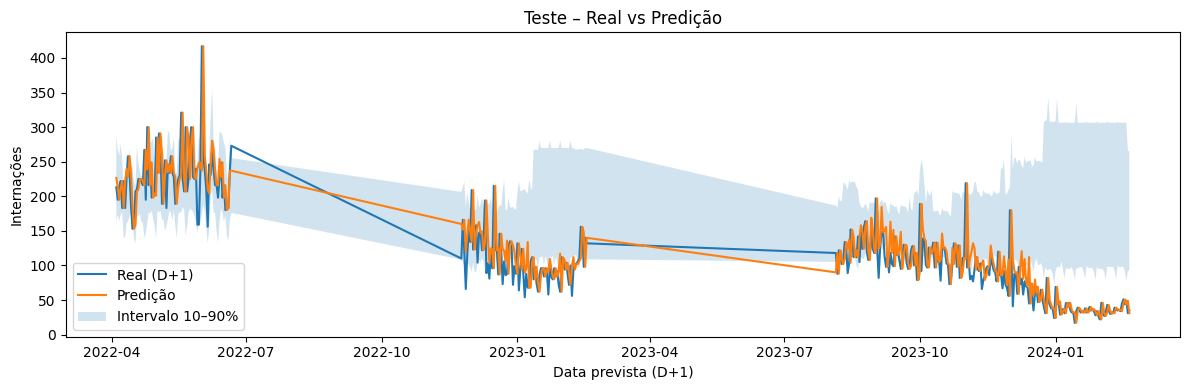

({'rel_thr': 0.2, 'abs_thr': 40.0, 'cv_rmse': 78.33190529004864},
 {'learning_rate': 0.05,
  'max_leaf_nodes': 31,
  'min_samples_leaf': 20,
  'l2': 0.5})

In [11]:
# Avaliação principal (ajuste janelas se quiser)
df_model.dropna(subset=["target"], inplace=True)  # remove linhas sem target
result = evaluate_models(df_model, valid_days=365, test_days=365, weight_mode="tanh")

# Tabelas (teste)
tabela = pd.DataFrame({k: v["test"] for k, v in result["metrics_overall"].items()}).T
tabela

tabela_jumps = pd.DataFrame({k: v["test"] for k, v in result["metrics_jumps"].items()}).T
tabela_jumps

# Predições + intervalos e gráfico
df_pred = make_df_pred(result)
plot_test_series(df_pred)

# Limiares do híbrido e hiperparâmetros do HGB usados
result["hybrid_thresholds"], result["best_hgb_params"]